# Сравнение случайных величин


## Виды случайных величин: 
1. Дискретные
2. Непрерывные

0.7020794635467706 -0.0023434494793108693


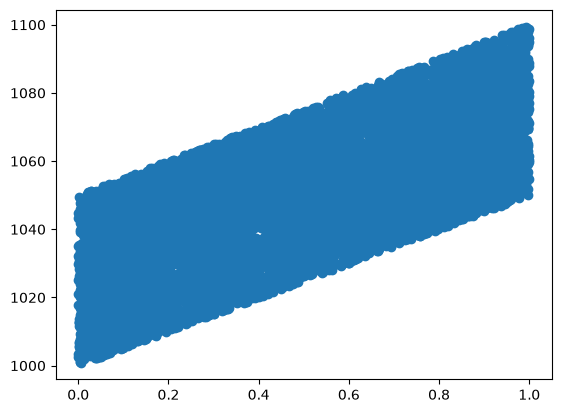

In [48]:
import numpy as np
import matplotlib.pyplot as plt
N=10000
x = np.random.rand(N)
xm = x.mean()
y = np.random.rand(N)
ym = y.mean()
t = 50*x + 1000 + np.random.rand(N)*50
# t = -50*x-2 # можно при - сделать отрицательную карреляцию
# t = np.exp(-50*x)
# t = np.sin(50*x)
tm = t.mean()
print(((x - xm)*(t-tm)).mean()/(x.std()*t.std()), ((x - xm)*(y - ym)).mean()/(x.std()*y.std())) # это называется коэфицент корреляции пирсона 
plt.scatter(x, t)


In [49]:
import scipy.stats as ss
R,_= ss.pearsonr(x, t)
print(f"pirsom = {R}")

pirsom = 0.7020794635467708


как посчитать зависимости междц случайными числами: 

сначала нужно понять как ведут себя данные
    мы дадим индек.0 1 2  3   4
допустим x у нас = 0 5 7  12  13 
допустим y у нас = 0 5 17 40 280

такая функция которая 


In [50]:
Rs,_ = ss.spearmanr(x, t)
print(f"spearman = {Rs}")

spearman = 0.6929583544855836


### коэффицент ранговой карреляции много разных, но проще всего коэффицент спирмана



Как сравнить категориальные переменные, сначчала возьем номинальные переменные

---

пример номинальной переменной: 

**свет** 

1. темный
2. светлый

**пол**

1. М
2. Д




| пол | темные | светлые |
|---| --- | --- |
| Мальчики | 3 |  12|
| Девочки | 2 |  1|

Для сравнения номинальныйх величин используется индекс РЕНДА - как он считается, итак мы с вами поделимся на группы по полу (2 группы) это у нас первое деление, и тоже самое сделаем поделимся на группы по второму признаку например свет, как посчитать: сначала мы допустим пронумеруем все точки (всех людей), далее у нас две группы точек, в двух группах по две подгруппы точек разных цветов, и мы начинаем сначала отдельно соединять в каждой группе подходящие одного цвета, потом в друггой так же и по итогу сравниваем где есть одинаковые пары, затем нам надо выяснить какие пары не попадают так же одновременно в двух категориях

далее мы суммируем все найденные две отдельные группы и делим на общее количество всех пар 



In [59]:
from sklearn.metrics import rand_score
s = np.array([0, 1, 0, 0, 0, 0, 1, 1]) # тут на практике мы обозначили две группы как выше по полу и по цвету, пофиг как
c = np.array([1,0, 0, 0, 1, 1, 1, 0])
RI = rand_score(s, c)
print(f"RI = {RI}")

RI = 0.4642857142857143


In [56]:
RI2 = rand_score(s, s-1)
print(f"RI2 = {RI2}")

RI2 = 1.0


### Порядковые 

порядковые с числовыми сравниваются очень просто: 

In [60]:
s1 = np.array([0, 1, 2, 0, 3, 1, 0, 1]) # Порядковые 
c1 = np.array([1.0,3.2, 2.2, 4.4, 1.5, 1.3, 1.4, 3.7]) # Числительные
RI = rand_score(s1, c1)
print(f"RI = {RI}")

RI = 0.7857142857142857


/home/platoxa/Documents/LocalColab/.venv/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


|  Порядковые  | Числовые |
| --- | --- |
|  Кур   | 1     |          
|млк | 15 |
|   ск  |  7   |
|нек| 0|


---
### Итак у вас есть номинальная переменная и числовая, вам неьобходимо сравнить номинальную с числовой, 
допустим у нас есть возраст и пол , значит нам надо проверить утверждения что у нас девушки будут младше парней как это проверить:

Надо выбрать те строки которые относятся к девочках и построить распределение вероятности и так же сделать у парней 

Если похоже, то нельзя сделать вывод, если нет, то можно уже сравнить

16.49706136340736 19.902938636592637
17.641384221354702 19.608615778645298


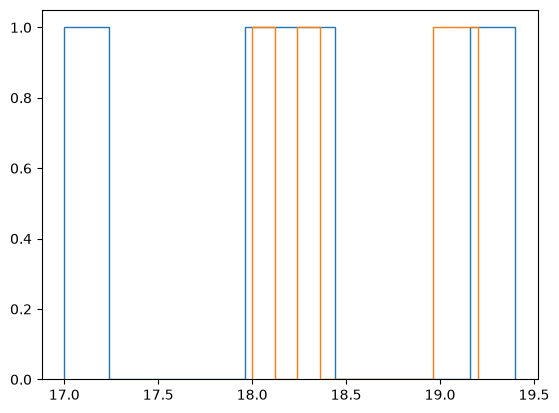

In [66]:
s2 = np.array([0, 1, 1, 0, 0, 1, 0, 1]) # Порядковые 
c2 = np.array([18.3, 19.2, 18.0, 17.0, 19.4, 19.0, 18.1, 18.3]) # Числительные
plt.hist(c2[s2==0], histtype='step', label='0')
plt.hist(c2[s2==1], histtype='step', label='0')
print(c2[s2==0].mean()-2*c2[s2==0].std(),c2[s2==0].mean()+2*c2[s2==0].std())
print(c2[s2==1].mean()-2*c2[s2==1].std(),c2[s2==1].mean()+2*c2[s2==1].std())

Короче то, что выше нельзя прямо сказать кто старше а кто младше, потому что расхождение маленькое 

1. |x1| < |x2|
2. x1 - 1 /= 1 - x2
3. если по графику не понятно что делать, а распределение лучше всего по идее но не всегда работает 


---

### Проверка гипотез

это когда вы пытаетесь дать ответь на какой то вопрос 
**основная гипотеза** - H (легко проверяется, понятная) = пример (человек высокий)
**Альтернативная гипотеза** - H1 (обратная основной) = пример (человек не высокий)
1. Левосторонная
2. Правосторонная
3. Двусторонная 